In [1]:
import pandas as pd
import numpy as np

# =========================================================
# DATA HANDLING
# =========================================================
import numpy as np
import pandas as pd

# =========================================================
# VISUALIZATION
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# MACHINE LEARNING
# =========================================================
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================================================
# IMBALANCED DATA
# =========================================================
from imblearn.over_sampling import SMOTE

# =========================================================
# EVALUATION
# =========================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# STATISTICS
# =========================================================
from scipy.stats import chi2_contingency

# =========================================================
# SETTINGS
# =========================================================
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("final_df.xlsx")
df

,vaccinated,vaccinated_5class,vaccinated_9class,antenatal_visits_yes,institutional_delivery,birth_order,mothers_age_gt_35,residence_urban,media_exposure,child_age_months,highest_educational_level,wealth_index,recieves_icds_benefits,facility_distance_issue,has_automobile,health_worker_visit,bcg,dpt1,polio1,dpt2,polio2,dpt3,polio3,measles1,pentavalent1,pentavalent2,pentavalent3,state,respondent_age,antenatal_visits,place_of_delivery,child_sex,has_motorcycle,has_car_truck,reads_newspaper,listens_radio,watches_tv,household_sex_female,sample_weight,psu,strata
0,1,4,8,1,1,4,0,0,0,13,1,3,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,35,5,21,2,0,0,0,0,0,0,196628,109,121
1,1,4,8,1,1,2,0,0,1,12,2,5,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,30,8,21,2,0,1,0,1,1,0,204798,140,121
2,1,4,8,1,1,3,1,0,0,12,2,3,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,37,10,24,1,0,0,0,0,0,0,220211,102,121
3,1,4,8,1,1,1,0,0,0,16,2,4,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,27,7,21,2,0,1,0,0,0,0,303213,133,122
4,1,4,8,1,1,2,0,0,1,20,0,2,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,34,10,21,1,0,0,0,1,0,0,352749,118,123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12372,0,0,0,1,1,1,0,1,1,15,3,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,37,28,4,21,2,1,0,2,1,0,0,39833,319,31
12373,1,4,8,1,1,2,0,1,1,21,2,4,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,37,33,9,21,2,0,1,1,2,2,0,38490,315,31
12374,1,4,8,1,1,3,0,0,1,16,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,37,28,4,21,2,0,1,0,2,1,0,54986,423,423
12375,1,4,8,0,1,3,1,0,1,13,0,2,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,37,38,1,24,1,0,0,0,0,1,0,50766,435,423


In [3]:
features = [
    'antenatal_visits_yes',
    'institutional_delivery',
    'birth_order',
    'mothers_age_gt_35',
    'residence_urban',
    'media_exposure',
    'child_age_months',
    'highest_educational_level',
    'wealth_index',
    'recieves_icds_benefits',
    'facility_distance_issue',
    'has_automobile',
    'health_worker_visit'
]

target = 'vaccinated'

df_model = df[features + [target]]

df_model

,antenatal_visits_yes,institutional_delivery,birth_order,mothers_age_gt_35,residence_urban,media_exposure,child_age_months,highest_educational_level,wealth_index,recieves_icds_benefits,facility_distance_issue,has_automobile,health_worker_visit,vaccinated
0,1,1,4,0,0,0,13,1,3,1,1,0,1,1
1,1,1,2,0,0,1,12,2,5,0,0,1,0,1
2,1,1,3,1,0,0,12,2,3,1,1,0,0,1
3,1,1,1,0,0,0,16,2,4,1,1,1,0,1
4,1,1,2,0,0,1,20,0,2,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12372,1,1,1,0,1,1,15,3,3,0,0,1,0,0
12373,1,1,2,0,1,1,21,2,4,0,1,1,0,1
12374,1,1,3,0,0,1,16,0,1,0,1,1,1,1
12375,0,1,3,1,0,1,13,0,2,0,1,0,1,1


In [4]:
df['vaccinated_5class'].value_counts()

vaccinated_5class
4    7804
3    1770
1    1063
0     916
2     824
Name: count, dtype: int64

In [5]:
df['vaccinated_5class'].value_counts()

# =========================================================
# FEATURES AND TARGET
# =========================================================

X = df_model[features]

y = df['vaccinated_5class']


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.3,

    random_state=42,

    stratify=y
)

###  MULTINOMIAL LOGISTIC REGRESSION



MULTINOMIAL LOGISTIC REGRESSION PERFORMANCE
      Metric  Training  Testing
0   Accuracy    0.7265   0.7170
1  Precision    0.6489   0.6339
2     Recall    0.7265   0.7170
3   F1 Score    0.6760   0.6636


OVERFITTING CHECK
Training F1 Score : 0.6760
Testing F1 Score  : 0.6636
Difference         : 0.0124

No significant overfitting detected.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.36      0.24      0.28       275
           1       0.29      0.07      0.11       319
           2       0.00      0.00      0.00       247
           3       0.37      0.49      0.42       531
           4       0.84      0.99      0.91      2342

    accuracy                           0.72      3714
   macro avg       0.37      0.36      0.34      3714
weighted avg       0.63      0.72      0.66      3714



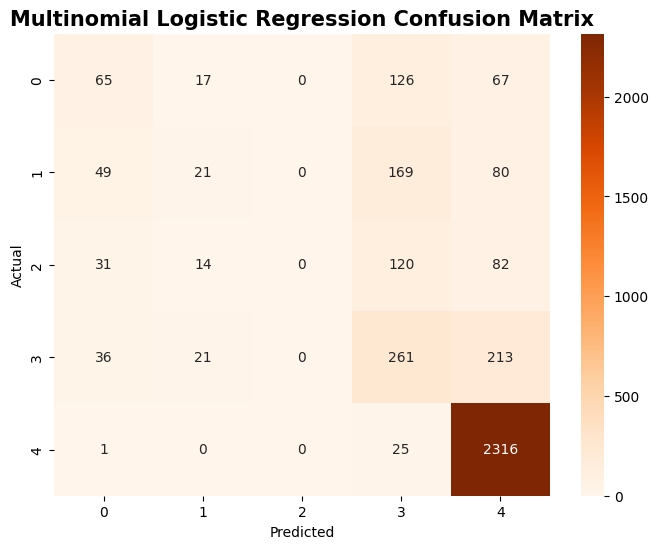



MULTINOMIAL LOGISTIC REGRESSION COEFFICIENTS
         antenatal_visits_yes  institutional_delivery  birth_order  \
Class_0               -0.8817                 -1.0386      -0.1760   
Class_1               -0.6576                 -0.4690      -0.1128   
Class_2               -0.6701                 -0.3039      -0.1666   
Class_3               -0.4821                 -0.1863      -0.2321   
Class_4                2.6915                  1.9977       0.6876   

         mothers_age_gt_35  residence_urban  media_exposure  child_age_months  \
Class_0            -1.4031           0.0958         -0.2929           -0.0439   
Class_1            -1.5635          -0.0336         -0.1651           -0.1085   
Class_2            -1.8716          -0.2023          0.0132           -0.0523   
Class_3            -2.0626          -0.2203         -0.0717           -0.0547   
Class_4             6.9009           0.3603          0.5165            0.2594   

         highest_educational_level  wealth_in

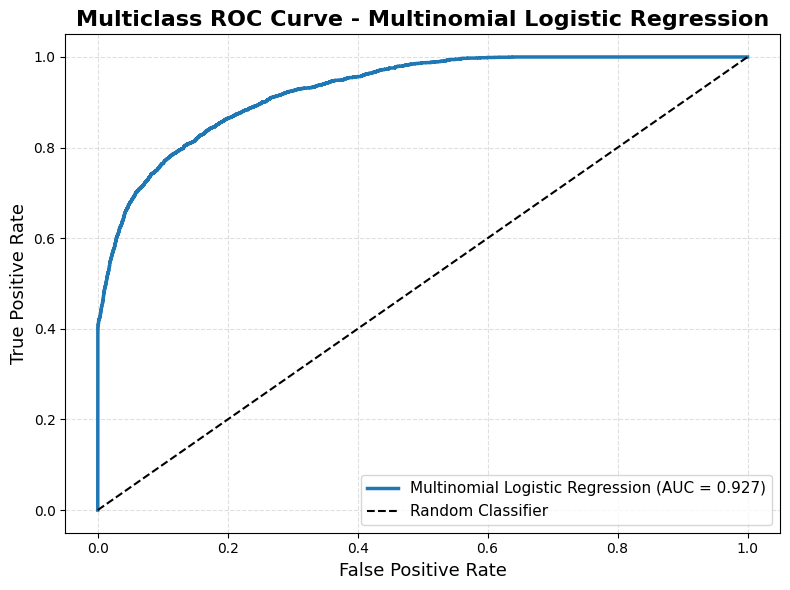

In [6]:
# =========================================================
# MULTINOMIAL LOGISTIC REGRESSION
# (WITHOUT REGULARIZATION)
# =========================================================

from sklearn.linear_model import LogisticRegression

# =========================================================
# FINAL MULTINOMIAL LOGISTIC REGRESSION MODEL
# =========================================================

multi_logit = LogisticRegression(

    penalty=None,          # No regularization

    solver='lbfgs',

    multi_class='multinomial',

    max_iter=5000,

    random_state=42
)

# =========================================================
# FIT MODEL
# =========================================================

multi_logit.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = multi_logit.predict(X_train)

train_prob = multi_logit.predict_proba(X_train)

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = multi_logit.predict(X_test)

test_prob = multi_logit.predict_proba(X_test)

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(
        y_train,
        train_pred
    ),

    'Precision': precision_score(
        y_train,
        train_pred,
        average='weighted'
    ),

    'Recall': recall_score(
        y_train,
        train_pred,
        average='weighted'
    ),

    'F1 Score': f1_score(
        y_train,
        train_pred,
        average='weighted'
    )
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(
        y_test,
        test_pred
    ),

    'Precision': precision_score(
        y_test,
        test_pred,
        average='weighted'
    ),

    'Recall': recall_score(
        y_test,
        test_pred,
        average='weighted'
    ),

    'F1 Score': f1_score(
        y_test,
        test_pred,
        average='weighted'
    )
}

# =========================================================
# PERFORMANCE COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n")
print("="*65)
print("MULTINOMIAL LOGISTIC REGRESSION PERFORMANCE")
print("="*65)

print(comparison)

# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Oranges',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "Multinomial Logistic Regression Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

# =========================================================
# OVERFITTING CHECK
# =========================================================

print("\n")
print("="*65)
print("OVERFITTING CHECK")
print("="*65)

train_f1 = train_metrics['F1 Score']

test_f1 = test_metrics['F1 Score']

difference = abs(train_f1 - test_f1)

print(f"Training F1 Score : {train_f1:.4f}")

print(f"Testing F1 Score  : {test_f1:.4f}")

print(f"Difference         : {difference:.4f}")

if difference < 0.03:

    print("\nNo significant overfitting detected.")

elif difference < 0.07:

    print("\nMild overfitting detected.")

else:

    print("\nSignificant overfitting detected.")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n")
print("="*65)
print("CLASSIFICATION REPORT")
print("="*65)

print(classification_report(
    y_test,
    test_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    "Multinomial Logistic Regression Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# COEFFICIENT TABLE
# =========================================================

coef_df = pd.DataFrame(

    multi_logit.coef_,

    columns=X_train.columns
)

coef_df.index = [
    f"Class_{cls}"
    for cls in multi_logit.classes_
]

coef_df = coef_df.round(4)

print("\n")
print("="*65)
print("MULTINOMIAL LOGISTIC REGRESSION COEFFICIENTS")
print("="*65)

print(coef_df)


# =========================================================
# MULTICLASS ROC-AUC CURVE
# =========================================================

from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

import numpy as np

# =========================================================
# BINARIZE MULTICLASS TARGET
# =========================================================

classes = np.unique(y_test)

y_test_bin = label_binarize(

    y_test,

    classes=classes
)

n_classes = y_test_bin.shape[1]

# =========================================================
# PREDICTED PROBABILITIES
# =========================================================

y_prob = multi_logit.predict_proba(X_test)

# =========================================================
# COMPUTE MICRO-AVERAGE ROC CURVE
# =========================================================

fpr, tpr, _ = roc_curve(

    y_test_bin.ravel(),

    y_prob.ravel()
)

roc_auc = auc(fpr, tpr)

# =========================================================
# PRINT ROC-AUC
# =========================================================

print("\n")
print("="*65)
print("MULTICLASS ROC-AUC")
print("="*65)

print(f"Micro-average ROC-AUC : {roc_auc:.4f}")

# =========================================================
# PLOT ROC CURVE
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2.5,

    label=f'Multinomial Logistic Regression (AUC = {roc_auc:.3f})'
)

# =========================================================
# RANDOM CLASSIFIER LINE
# =========================================================

plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    color='black',

    linewidth=1.5,

    label='Random Classifier'
)

# =========================================================
# TITLES
# =========================================================

plt.title(

    "Multiclass ROC Curve - Multinomial Logistic Regression",

    fontsize=16,

    fontweight='bold'
)

plt.xlabel(

    "False Positive Rate",

    fontsize=13
)

plt.ylabel(

    "True Positive Rate",

    fontsize=13
)

# =========================================================
# LEGEND
# =========================================================

plt.legend(

    loc='lower right',

    fontsize=11
)

# =========================================================
# GRID
# =========================================================

plt.grid(

    linestyle='--',

    alpha=0.4
)

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

plt.show()

###  MULTICLASS RANDOM FOREST



MULTICLASS RANDOM FOREST PERFORMANCE
      Metric  Training  Testing
0   Accuracy    0.7806   0.6979
1  Precision    0.7838   0.6061
2     Recall    0.7806   0.6979
3   F1 Score    0.7469   0.6322


OVERFITTING CHECK
Training F1 Score : 0.7469
Testing F1 Score  : 0.6322
Difference         : 0.1147

Significant overfitting detected.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.34      0.20      0.25       275
           1       0.33      0.07      0.12       319
           2       0.11      0.01      0.02       247
           3       0.37      0.33      0.35       531
           4       0.78      1.00      0.88      2342

    accuracy                           0.70      3714
   macro avg       0.39      0.32      0.32      3714
weighted avg       0.61      0.70      0.63      3714



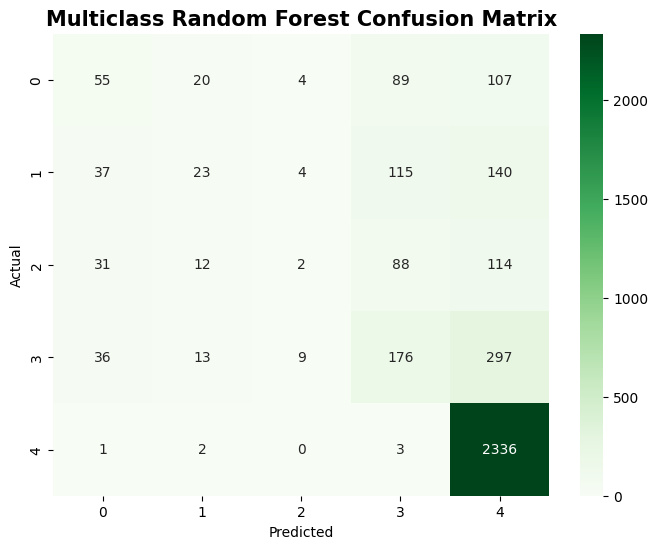



FEATURE IMPORTANCE
                     Variable  Importance
12        health_worker_visit      0.1426
6            child_age_months      0.1126
0        antenatal_visits_yes      0.1028
8                wealth_index      0.0995
9      recieves_icds_benefits      0.0921
2                 birth_order      0.0916
10    facility_distance_issue      0.0783
11             has_automobile      0.0724
7   highest_educational_level      0.0523
1      institutional_delivery      0.0501
3           mothers_age_gt_35      0.0490
5              media_exposure      0.0318
4             residence_urban      0.0250


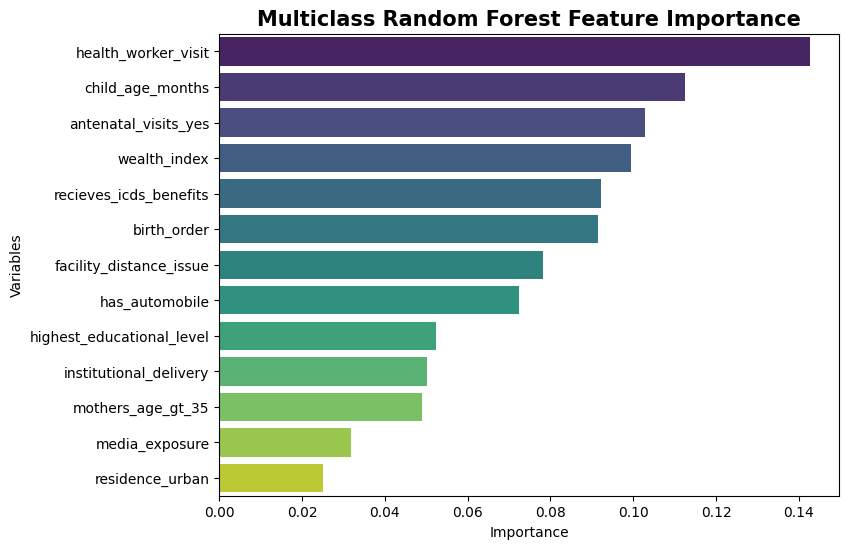



MULTICLASS ROC-AUC
Micro-average ROC-AUC : 0.9123


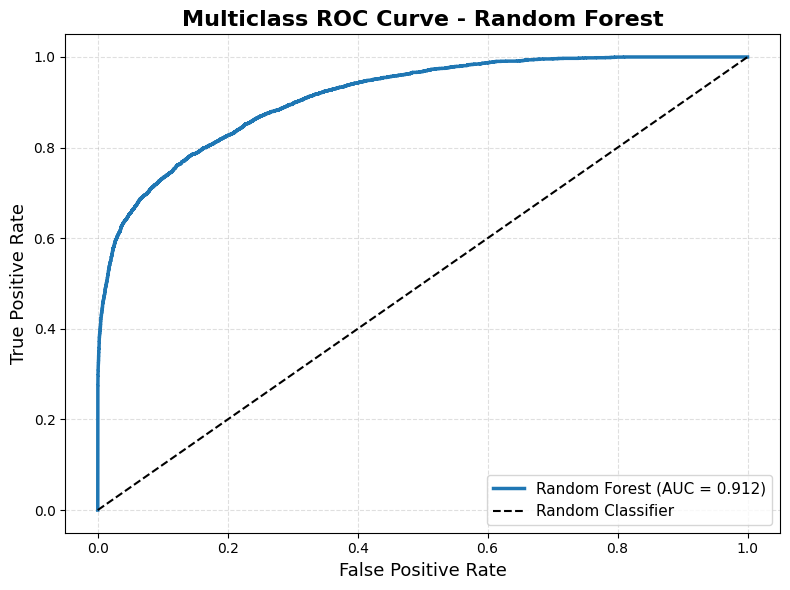

In [7]:
# =========================================================
# MULTICLASS RANDOM FOREST
# (WITHOUT CLASS WEIGHTS)
# =========================================================

from sklearn.ensemble import RandomForestClassifier

# =========================================================
# FINAL RANDOM FOREST MODEL
# =========================================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    min_samples_split=2,

    min_samples_leaf=1,

    max_features='sqrt',

    random_state=42
)

# =========================================================
# FIT MODEL
# =========================================================

rf_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = rf_model.predict(X_train)

train_prob = rf_model.predict_proba(X_train)

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = rf_model.predict(X_test)

test_prob = rf_model.predict_proba(X_test)

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(
        y_train,
        train_pred
    ),

    'Precision': precision_score(
        y_train,
        train_pred,
        average='weighted'
    ),

    'Recall': recall_score(
        y_train,
        train_pred,
        average='weighted'
    ),

    'F1 Score': f1_score(
        y_train,
        train_pred,
        average='weighted'
    )
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(
        y_test,
        test_pred
    ),

    'Precision': precision_score(
        y_test,
        test_pred,
        average='weighted'
    ),

    'Recall': recall_score(
        y_test,
        test_pred,
        average='weighted'
    ),

    'F1 Score': f1_score(
        y_test,
        test_pred,
        average='weighted'
    )
}

# =========================================================
# PERFORMANCE COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

print("\n")
print("="*65)
print("MULTICLASS RANDOM FOREST PERFORMANCE")
print("="*65)

print(comparison)

# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Greens',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "Multiclass Random Forest Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

# =========================================================
# OVERFITTING CHECK
# =========================================================

print("\n")
print("="*65)
print("OVERFITTING CHECK")
print("="*65)

train_f1 = train_metrics['F1 Score']

test_f1 = test_metrics['F1 Score']

difference = abs(train_f1 - test_f1)

print(f"Training F1 Score : {train_f1:.4f}")

print(f"Testing F1 Score  : {test_f1:.4f}")

print(f"Difference         : {difference:.4f}")

if difference < 0.03:

    print("\nNo significant overfitting detected.")

elif difference < 0.07:

    print("\nMild overfitting detected.")

else:

    print("\nSignificant overfitting detected.")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n")
print("="*65)
print("CLASSIFICATION REPORT")
print("="*65)

print(classification_report(
    y_test,
    test_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Multiclass Random Forest Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({

    'Variable': X_train.columns,

    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df['Importance'] = importance_df[
    'Importance'
].round(4)

print("\n")
print("="*65)
print("FEATURE IMPORTANCE")
print("="*65)

print(importance_df)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(8,6))

sns.barplot(

    x='Importance',

    y='Variable',

    data=importance_df,

    palette='viridis'
)

plt.title(
    "Multiclass Random Forest Feature Importance",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Importance")

plt.ylabel("Variables")

plt.show()

# =========================================================
# MULTICLASS ROC-AUC CURVE
# =========================================================

from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc

import numpy as np

# =========================================================
# BINARIZE TARGET
# =========================================================

classes = np.unique(y_test)

y_test_bin = label_binarize(

    y_test,

    classes=classes
)

# =========================================================
# MICRO-AVERAGE ROC CURVE
# =========================================================

fpr, tpr, _ = roc_curve(

    y_test_bin.ravel(),

    test_prob.ravel()
)

roc_auc = auc(fpr, tpr)

# =========================================================
# PRINT ROC-AUC
# =========================================================

print("\n")
print("="*65)
print("MULTICLASS ROC-AUC")
print("="*65)

print(f"Micro-average ROC-AUC : {roc_auc:.4f}")

# =========================================================
# ROC CURVE PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2.5,

    label=f'Random Forest (AUC = {roc_auc:.3f})'
)

# Random classifier
plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    color='black',

    linewidth=1.5,

    label='Random Classifier'
)

# =========================================================
# TITLE
# =========================================================

plt.title(

    "Multiclass ROC Curve - Random Forest",

    fontsize=16,

    fontweight='bold'
)

plt.xlabel(

    "False Positive Rate",

    fontsize=13
)

plt.ylabel(

    "True Positive Rate",

    fontsize=13
)

plt.legend(
    loc='lower right',
    fontsize=11
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

###   MULTICLASS XGBOOST



MULTICLASS XGBOOST PERFORMANCE
      Metric  Training  Testing
0   Accuracy    0.7979   0.7025
1  Precision    0.7863   0.6388
2     Recall    0.7979   0.7025
3   F1 Score    0.7759   0.6620


OVERFITTING CHECK
Training F1 Score : 0.7759
Testing F1 Score  : 0.6620
Difference         : 0.1139

Significant overfitting detected.


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.32      0.21      0.25       275
           1       0.30      0.14      0.19       319
           2       0.14      0.04      0.07       247
           3       0.37      0.41      0.39       531
           4       0.83      0.97      0.90      2342

    accuracy                           0.70      3714
   macro avg       0.39      0.35      0.36      3714
weighted avg       0.64      0.70      0.66      3714



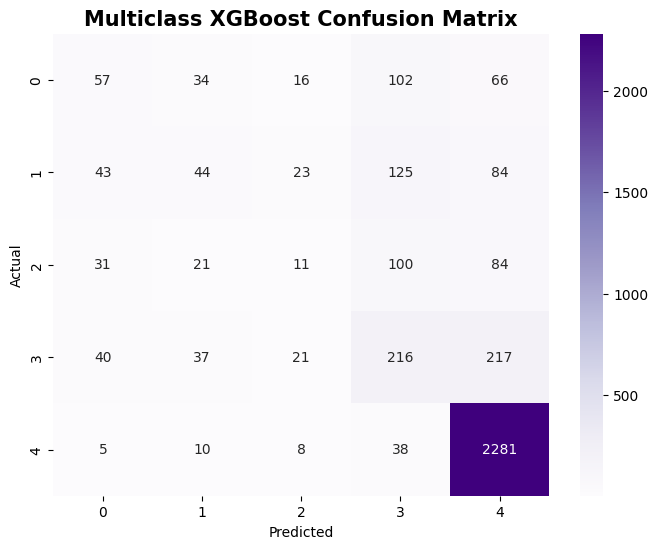



FEATURE IMPORTANCE
                     Variable  Importance
3           mothers_age_gt_35      0.1614
12        health_worker_visit      0.1294
0        antenatal_visits_yes      0.1123
9      recieves_icds_benefits      0.0974
10    facility_distance_issue      0.0924
11             has_automobile      0.0879
1      institutional_delivery      0.0708
8                wealth_index      0.0553
2                 birth_order      0.0444
6            child_age_months      0.0406
5              media_exposure      0.0373
4             residence_urban      0.0359
7   highest_educational_level      0.0348


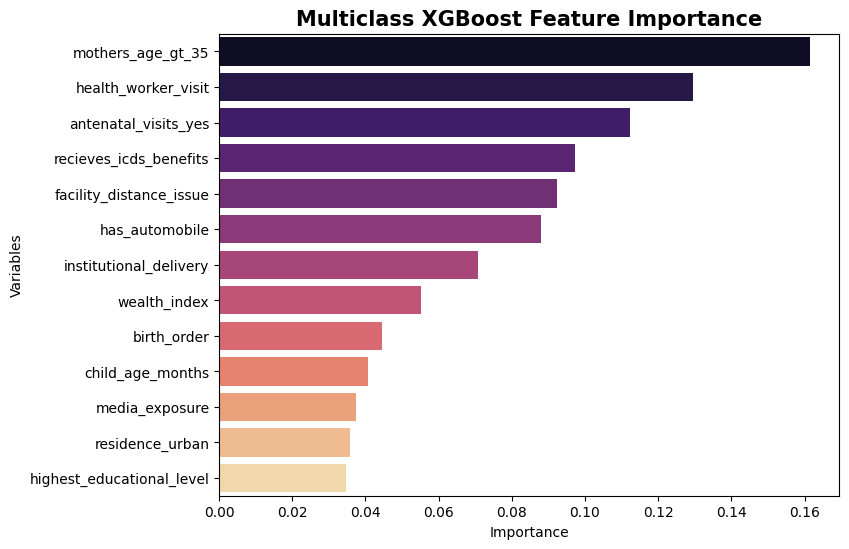



MULTICLASS ROC-AUC
Micro-average ROC-AUC : 0.9184


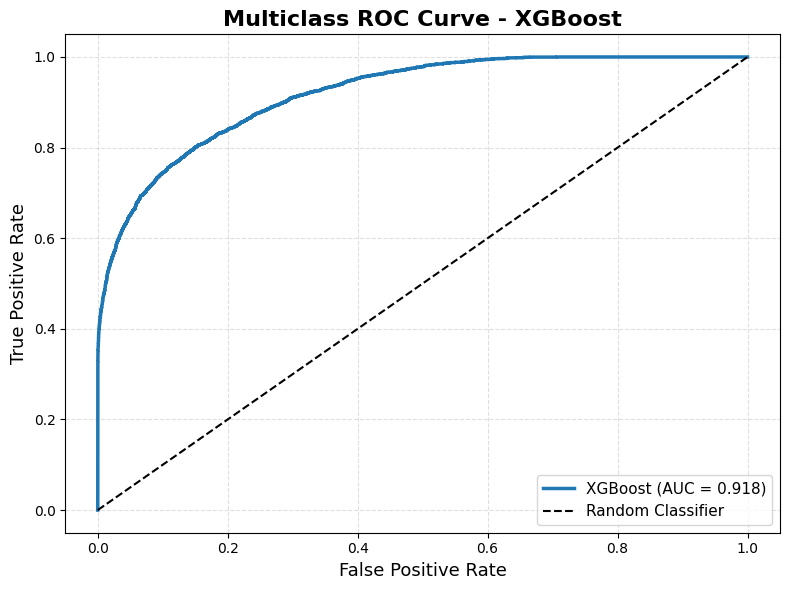

In [8]:
# =========================================================
# MULTICLASS XGBOOST
# (WITHOUT CLASS WEIGHTS)
# =========================================================

from xgboost import XGBClassifier

# =========================================================
# FINAL XGBOOST MODEL
# =========================================================

xgb_model = XGBClassifier(

    objective='multi:softprob',

    num_class=len(np.unique(y_train)),

    eval_metric='mlogloss',

    n_estimators=200,

    max_depth=5,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=1.0,

    gamma=0.1,

    random_state=42
)

# =========================================================
# FIT MODEL
# =========================================================

xgb_model.fit(X_train, y_train)

# =========================================================
# TRAINING PREDICTIONS
# =========================================================

train_pred = xgb_model.predict(X_train)

train_prob = xgb_model.predict_proba(X_train)

# =========================================================
# TESTING PREDICTIONS
# =========================================================

test_pred = xgb_model.predict(X_test)

test_prob = xgb_model.predict_proba(X_test)

# =========================================================
# IMPORT METRICS
# =========================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# TRAINING METRICS
# =========================================================

train_metrics = {

    'Accuracy': accuracy_score(
        y_train,
        train_pred
    ),

    'Precision': precision_score(
        y_train,
        train_pred,
        average='weighted'
    ),

    'Recall': recall_score(
        y_train,
        train_pred,
        average='weighted'
    ),

    'F1 Score': f1_score(
        y_train,
        train_pred,
        average='weighted'
    )
}

# =========================================================
# TESTING METRICS
# =========================================================

test_metrics = {

    'Accuracy': accuracy_score(
        y_test,
        test_pred
    ),

    'Precision': precision_score(
        y_test,
        test_pred,
        average='weighted'
    ),

    'Recall': recall_score(
        y_test,
        test_pred,
        average='weighted'
    ),

    'F1 Score': f1_score(
        y_test,
        test_pred,
        average='weighted'
    )
}

# =========================================================
# PERFORMANCE COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    'Metric': train_metrics.keys(),

    'Training': train_metrics.values(),

    'Testing': test_metrics.values()
})

comparison.iloc[:,1:] = comparison.iloc[:,1:].round(4)

print("\n")
print("="*65)
print("MULTICLASS XGBOOST PERFORMANCE")
print("="*65)

print(comparison)

# =========================================================
# STYLED TABLE
# =========================================================

comparison.style\
    .background_gradient(
        cmap='Purples',
        subset=['Training', 'Testing']
    )\
    .set_caption(
        "Multiclass XGBoost Performance"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

# =========================================================
# OVERFITTING CHECK
# =========================================================

print("\n")
print("="*65)
print("OVERFITTING CHECK")
print("="*65)

train_f1 = train_metrics['F1 Score']

test_f1 = test_metrics['F1 Score']

difference = abs(train_f1 - test_f1)

print(f"Training F1 Score : {train_f1:.4f}")

print(f"Testing F1 Score  : {test_f1:.4f}")

print(f"Difference         : {difference:.4f}")

if difference < 0.03:

    print("\nNo significant overfitting detected.")

elif difference < 0.07:

    print("\nMild overfitting detected.")

else:

    print("\nSignificant overfitting detected.")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n")
print("="*65)
print("CLASSIFICATION REPORT")
print("="*65)

print(classification_report(
    y_test,
    test_pred
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    "Multiclass XGBoost Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({

    'Variable': X_train.columns,

    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df['Importance'] = importance_df[
    'Importance'
].round(4)

print("\n")
print("="*65)
print("FEATURE IMPORTANCE")
print("="*65)

print(importance_df)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(8,6))

sns.barplot(

    x='Importance',

    y='Variable',

    data=importance_df,

    palette='magma'
)

plt.title(
    "Multiclass XGBoost Feature Importance",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Importance")

plt.ylabel("Variables")

plt.show()

# =========================================================
# MULTICLASS ROC-AUC CURVE
# =========================================================

from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve, auc

import numpy as np

# =========================================================
# BINARIZE TARGET
# =========================================================

classes = np.unique(y_test)

y_test_bin = label_binarize(

    y_test,

    classes=classes
)

# =========================================================
# MICRO-AVERAGE ROC CURVE
# =========================================================

fpr, tpr, _ = roc_curve(

    y_test_bin.ravel(),

    test_prob.ravel()
)

roc_auc = auc(fpr, tpr)

# =========================================================
# PRINT ROC-AUC
# =========================================================

print("\n")
print("="*65)
print("MULTICLASS ROC-AUC")
print("="*65)

print(f"Micro-average ROC-AUC : {roc_auc:.4f}")

# =========================================================
# ROC CURVE PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2.5,

    label=f'XGBoost (AUC = {roc_auc:.3f})'
)

# Random classifier
plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    color='black',

    linewidth=1.5,

    label='Random Classifier'
)

# =========================================================
# TITLE
# =========================================================

plt.title(

    "Multiclass ROC Curve - XGBoost",

    fontsize=16,

    fontweight='bold'
)

plt.xlabel(

    "False Positive Rate",

    fontsize=13
)

plt.ylabel(

    "True Positive Rate",

    fontsize=13
)

plt.legend(
    loc='lower right',
    fontsize=11
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

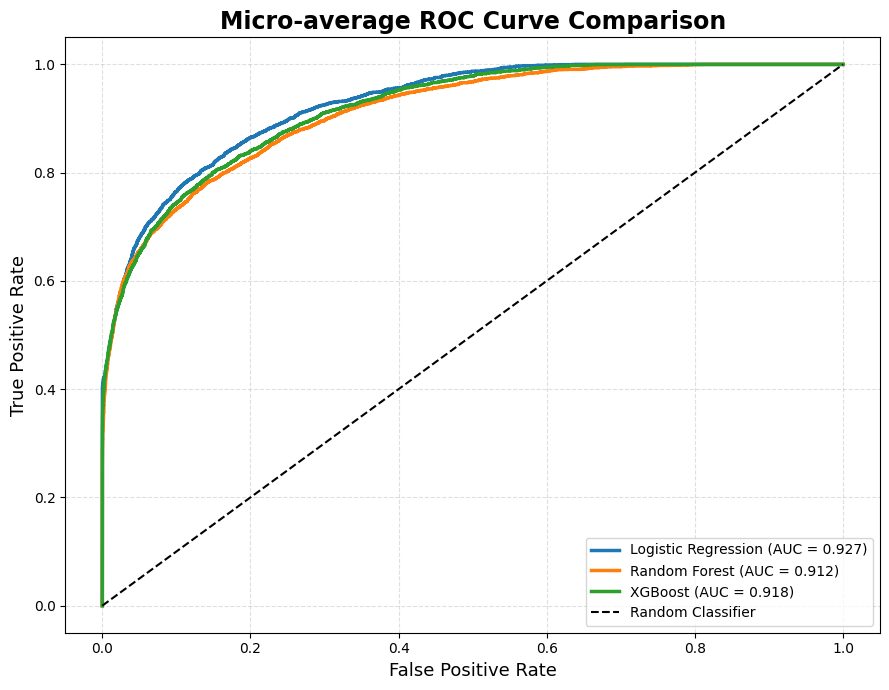

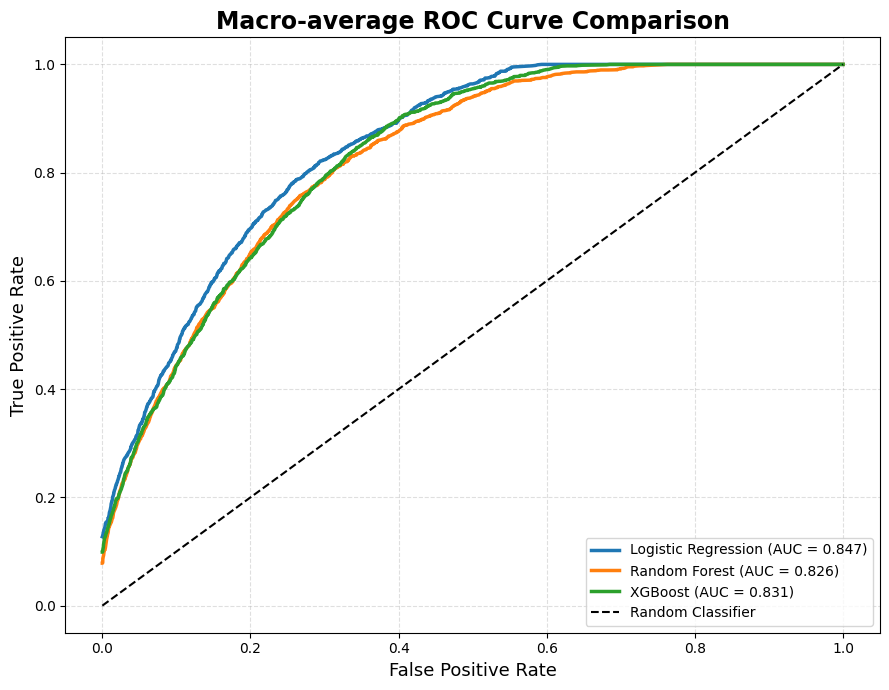



MULTICLASS ROC-AUC SUMMARY
                 Model  Macro ROC-AUC  Micro ROC-AUC
0  Logistic Regression         0.8471         0.9269
1        Random Forest         0.8264         0.9123
2              XGBoost         0.8313         0.9184


,Model,Macro ROC-AUC,Micro ROC-AUC
0,Logistic Regression,0.847100,0.926900
1,Random Forest,0.826400,0.912300
2,XGBoost,0.831300,0.918400


In [9]:
# =========================================================
# MULTICLASS ROC-AUC COMPARISON
# LOGISTIC REGRESSION vs RANDOM FOREST vs XGBOOST
# MICRO & MACRO AVERAGE ROC CURVES
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc
)

# =========================================================
# BINARIZE MULTICLASS TARGET
# =========================================================

classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

n_classes = y_test_bin.shape[1]

# =========================================================
# PREDICTED PROBABILITIES
# =========================================================

logit_prob = multi_logit.predict_proba(X_test)

rf_prob = rf_model.predict_proba(X_test)

xgb_prob = xgb_model.predict_proba(X_test)

# =========================================================
# FUNCTION TO COMPUTE MICRO-AVERAGE ROC
# =========================================================

def compute_micro_roc(y_true, y_prob):

    fpr, tpr, _ = roc_curve(

        y_true.ravel(),

        y_prob.ravel()
    )

    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc

# =========================================================
# FUNCTION TO COMPUTE MACRO-AVERAGE ROC
# =========================================================

def compute_macro_roc(y_true, y_prob, n_classes):

    fpr = dict()

    tpr = dict()

    roc_auc = dict()

    # ROC for each class
    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true[:, i],
            y_prob[:, i]
        )

        roc_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    # Combine all FPR points
    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(n_classes)]
        )
    )

    # Mean TPR
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= n_classes

    macro_auc = auc(
        all_fpr,
        mean_tpr
    )

    return all_fpr, mean_tpr, macro_auc

# =========================================================
# LOGISTIC REGRESSION ROC
# =========================================================

logit_micro_fpr, logit_micro_tpr, logit_micro_auc = compute_micro_roc(

    y_test_bin,

    logit_prob
)

logit_macro_fpr, logit_macro_tpr, logit_macro_auc = compute_macro_roc(

    y_test_bin,

    logit_prob,

    n_classes
)

# =========================================================
# RANDOM FOREST ROC
# =========================================================

rf_micro_fpr, rf_micro_tpr, rf_micro_auc = compute_micro_roc(

    y_test_bin,

    rf_prob
)

rf_macro_fpr, rf_macro_tpr, rf_macro_auc = compute_macro_roc(

    y_test_bin,

    rf_prob,

    n_classes
)

# =========================================================
# XGBOOST ROC
# =========================================================

xgb_micro_fpr, xgb_micro_tpr, xgb_micro_auc = compute_micro_roc(

    y_test_bin,

    xgb_prob
)

xgb_macro_fpr, xgb_macro_tpr, xgb_macro_auc = compute_macro_roc(

    y_test_bin,

    xgb_prob,

    n_classes
)

# =========================================================
# PLOT MICRO-AVERAGE ROC CURVES
# =========================================================

plt.figure(figsize=(9,7))

plt.plot(

    logit_micro_fpr,

    logit_micro_tpr,

    linewidth=2.5,

    label=f'Logistic Regression (AUC = {logit_micro_auc:.3f})'
)

plt.plot(

    rf_micro_fpr,

    rf_micro_tpr,

    linewidth=2.5,

    label=f'Random Forest (AUC = {rf_micro_auc:.3f})'
)

plt.plot(

    xgb_micro_fpr,

    xgb_micro_tpr,

    linewidth=2.5,

    label=f'XGBoost (AUC = {xgb_micro_auc:.3f})'
)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    color='black',

    linewidth=1.5,

    label='Random Classifier'
)

plt.title(

    "Micro-average ROC Curve Comparison",

    fontsize=17,

    fontweight='bold'
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.legend(
    loc='lower right',
    fontsize=10
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

# =========================================================
# PLOT MACRO-AVERAGE ROC CURVES
# =========================================================

plt.figure(figsize=(9,7))

plt.plot(

    logit_macro_fpr,

    logit_macro_tpr,

    linewidth=2.5,

    label=f'Logistic Regression (AUC = {logit_macro_auc:.3f})'
)

plt.plot(

    rf_macro_fpr,

    rf_macro_tpr,

    linewidth=2.5,

    label=f'Random Forest (AUC = {rf_macro_auc:.3f})'
)

plt.plot(

    xgb_macro_fpr,

    xgb_macro_tpr,

    linewidth=2.5,

    label=f'XGBoost (AUC = {xgb_macro_auc:.3f})'
)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    color='black',

    linewidth=1.5,

    label='Random Classifier'
)

plt.title(

    "Macro-average ROC Curve Comparison",

    fontsize=17,

    fontweight='bold'
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.legend(
    loc='lower right',
    fontsize=10
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

# =========================================================
# ROC-AUC SUMMARY TABLE
# =========================================================

roc_summary = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Random Forest',

        'XGBoost'
    ],

    'Macro ROC-AUC': [

        round(logit_macro_auc,4),

        round(rf_macro_auc,4),

        round(xgb_macro_auc,4)
    ],

    'Micro ROC-AUC': [

        round(logit_micro_auc,4),

        round(rf_micro_auc,4),

        round(xgb_micro_auc,4)
    ]
})

print("\n")
print("="*65)
print("MULTICLASS ROC-AUC SUMMARY")
print("="*65)

print(roc_summary)

# =========================================================
# STYLED TABLE
# =========================================================

roc_summary.style\
    .background_gradient(
        cmap='Purples',
        subset=['Macro ROC-AUC', 'Micro ROC-AUC']
    )\
    .set_caption(
        "Multiclass ROC-AUC Comparison"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

In [10]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score,
    confusion_matrix
)

import pandas as pd
import numpy as np

# =========================================================
# PREDICTIONS
# =========================================================

logit_pred = multi_logit.predict(X_test)

rf_pred = rf_model.predict(X_test)

xgb_pred = xgb_model.predict(X_test)

# =========================================================
# PREDICTED PROBABILITIES
# =========================================================

logit_prob = multi_logit.predict_proba(X_test)

rf_prob = rf_model.predict_proba(X_test)

xgb_prob = xgb_model.predict_proba(X_test)

# =========================================================
# STORE MODELS
# =========================================================

models = {

    'Multinomial Logistic Regression': (

        logit_pred,
        logit_prob
    ),

    'Random Forest': (

        rf_pred,
        rf_prob
    ),

    'XGBoost': (

        xgb_pred,
        xgb_prob
    )
}

# =========================================================
# EMPTY LIST
# =========================================================

rows = []

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for model_name, (y_pred, y_prob) in models.items():

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Recall / Sensitivity
    sensitivity = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # F1 Score
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Macro ROC-AUC
    macro_auc = roc_auc_score(

        y_test,

        y_prob,

        multi_class='ovr',

        average='macro'
    )

    # Micro ROC-AUC
    micro_auc = roc_auc_score(

        y_test,

        y_prob,

        multi_class='ovr',

        average='micro'
    )

    # Cohen Kappa
    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    rows.append({

        'Model': model_name,

        'Accuracy (%)':
            round(accuracy * 100, 2),

        'Weighted Precision (%)':
            round(precision * 100, 2),

        'Weighted Recall (%)':
            round(sensitivity * 100, 2),

        'Weighted F1-Score (%)':
            round(f1 * 100, 2),

        'Macro ROC-AUC (%)':
            round(macro_auc * 100, 2),

        'Micro ROC-AUC (%)':
            round(micro_auc * 100, 2),

        'Kappa (%)':
            round(kappa * 100, 2)
    })

# =========================================================
# CREATE FINAL TABLE
# =========================================================

comparison_table = pd.DataFrame(rows)

# =========================================================
# SORT BY MICRO ROC-AUC
# =========================================================

comparison_table = comparison_table.sort_values(

    by='Micro ROC-AUC (%)',

    ascending=False
)

# =========================================================
# DISPLAY TABLE
# =========================================================

print("\n")
print("="*120)
print("MULTICLASS MODEL COMPARISON TABLE")
print("="*120)

display(comparison_table)

# =========================================================
# STYLED TABLE
# =========================================================

comparison_table.style\
    .background_gradient(
        cmap='Purples',
        subset=[
            'Accuracy (%)',
            'Weighted Precision (%)',
            'Weighted Recall (%)',
            'Weighted F1-Score (%)',
            'Macro ROC-AUC (%)',
            'Micro ROC-AUC (%)',
            'Kappa (%)'
        ]
    )\
    .set_caption(
        "Multiclass Classification Model Comparison"
    )\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })



MULTICLASS MODEL COMPARISON TABLE


,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1-Score (%),Macro ROC-AUC (%),Micro ROC-AUC (%),Kappa (%)
0,Multinomial Logistic Regression,71.70,63.39,71.70,66.36,84.70,92.69,43.34
2,XGBoost,70.25,63.88,70.25,66.20,83.11,91.84,41.14
1,Random Forest,69.79,60.61,69.79,63.22,82.63,91.23,35.50


,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1-Score (%),Macro ROC-AUC (%),Micro ROC-AUC (%),Kappa (%)
0,Multinomial Logistic Regression,71.700000,63.390000,71.700000,66.360000,84.700000,92.690000,43.340000
2,XGBoost,70.250000,63.880000,70.250000,66.200000,83.110000,91.840000,41.140000
1,Random Forest,69.790000,60.610000,69.790000,63.220000,82.630000,91.230000,35.500000
